Testing code to run an RK4 solver to solve the Lane-Emden equation for a given polytropic index. Based off notes here: https://users.monash.edu.au/~johnl/astro/ASP3012/Lab1-2009.pdf


In [1]:
# Sec 3.1: Euler method
# x0 = 0, y0 = 1

#dy/dx = y (analytic soln y= exp(x))
import numpy as np
from matplotlib import pyplot as plt
h = 0.02
x_0 = 0
x_1 = 1
n = int((x_1 - x_0)/h + 1)
x = np.linspace(x_0,x_1,n)
y_0 = 1
y = np.zeros_like(x)
y[0] = y_0
for i in range(n-1):
    y[i+1] = y[i] + h*y[i]

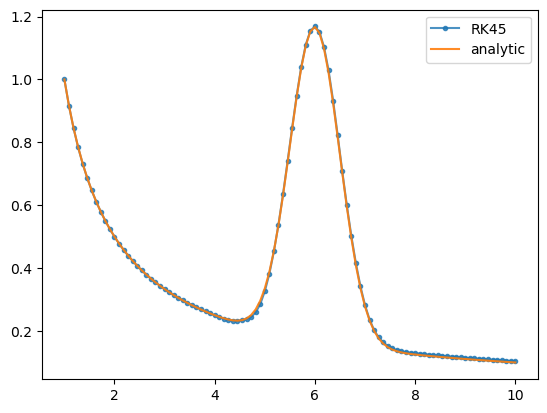

In [2]:
# RK45 method
from scipy.integrate import solve_ivp

def f(t,y):
    return -1/t**2 - 4*(t-6)*np.exp(-2*(t-6)**2)
t_0 = 1
y_0 = np.array([1,])
t_bound = 10
t_eval = np.linspace(t_0,t_bound, 100)
t_span = np.array([t_0, t_bound])
y_sol = solve_ivp(f,t_span,y_0, method="RK45", t_eval = t_eval)
y_analytic = 1/t_eval + np.exp(-2*(t_eval-6)**2)

fig,ax = plt.subplots()
# ax.plot(x,y, '.-', label='euler', alpha = 0.8)
ax.plot(t_eval, y_sol.y[0], '.-', alpha = 0.8, label="RK45")
# ax.plot(x, np.exp(x), alpha = 0.9, label="analytic")
ax.plot(t_eval, y_analytic, alpha=0.9, label='analytic')
ax.legend()
plt.show()

Now a second order ODE of the form

$\frac{d^2 y}{dx^2} = f(x,y,\frac{dy}{dx})$.

If we let $z = y'$, then we decompose into two first order ODEs

$\frac{dz}{dx} = f(x,y,z)$,
$\frac{dy}{dx} = g(x,y,z)$

where here $g(x,y,z) = z$. For initial conditions $x = x_0$, $y=y_0$, $z= z_0 = dy/dx|_{x_0}$

For example, take the simple harmonic motion equation
$\frac{d^2 y}{dx^2} + y = 0$

which becomes
$\frac{dz}{dx} = -y$,
$\frac{dy}{dx} = z$

so $f(x,y,z) = -y$, and $g(x,y,z) = z$

This has a general solution $f(x) = A \sin(x) + B\cos(x)$

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.173e-02 ...  3.110e+00  3.142e+00]
        y: [[ 0.000e+00  3.173e-02 ...  3.114e-02 -5.877e-04]
            [ 1.000e+00  9.995e-01 ... -9.995e-01 -1.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 44
     njev: 0
      nlu: 0


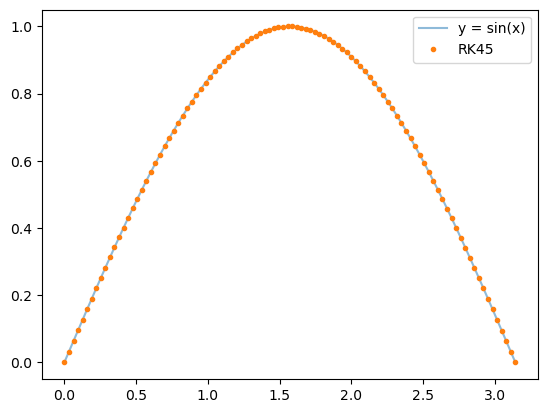

In [6]:
x_0 = 0
x_1 = np.pi
y_0 = 0
z_0 = 1

x = np.linspace(x_0,x_1,100)
y_analytic = np.sin(x)

# define RHS function that takes in t and the state vector y_vec = [y, dydt] that get entered into the RHS equations. solve_ivp requires function to return the derivatives of y_vec. Since y_vec = [y,dydt], then fun should return [dydt, d^2ydt^2] = [g, f]
def fun(t,y_vec):
    y, dydt = y_vec
    zdot = -y
    ydot = dydt
    return [ydot,zdot]

# Initial conditions
y0 = [y_0, z_0]

sol = solve_ivp(fun, t_span=[x_0,x_1],y0=y0,method='RK45', t_eval=x)

print(sol)

fig,ax = plt.subplots()
ax.plot(x,y_analytic, alpha = 0.5, label='y = sin(x)')
ax.plot(x, sol.y[0], '.', label='RK45')
ax.legend()
plt.show()

Now the Lane Emden equation

$\frac{d}{d\xi}\left(\xi^2\frac{d\theta}{d\xi}\right) = -\xi^2\theta^n$

which may be expanded

$\xi^2\frac{d^2\theta}{d\xi^2} + 2 \xi \frac{d\theta}{d\xi} = -\xi^2\theta^n$

Let $z = d\theta/d\xi$, then

$$ 
\begin{align}
    & \frac{dz}{d\xi} = -\frac{1}{\xi^2}\left(2\xi z + \xi^2\theta^n\right)\\
    & \frac{d\theta}{d\xi} = z
\end{align}
$$

So the RHS function is $f(\xi, \theta, d\theta/d\xi) = f(\xi, \theta, z)$. If we do everything in the $(x,y,z)$ notation it becomes
$$
\begin{align}
& \frac{dy}{dx} = z \\
& \frac{dz}{dx} = -\frac{1}{x^2}\left(2xz + x^2 y^n\right)
\end{align}
$$



387


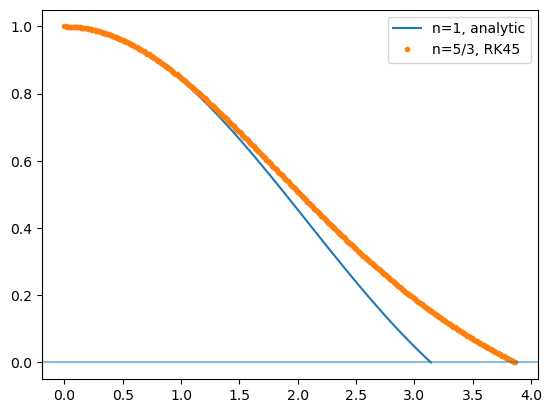

In [33]:
def lane_emd(x,y_vec):
    y, z = y_vec
    dydx = z
    n = 5./3.
    dzdx = -(2*x*z + x**2 * np.maximum(y, 0)**n) / x**2
    return [dydx, dzdx]

def theta_zero(xi, y):
        return y[0]           # event triggers when theta = 0
    
theta_zero.terminal  = True    # stop integration at this event
theta_zero.direction = -1      # only trigger on downward zero crossing

x = np.linspace(0.01,np.pi,100)
y_analytic = np.sin(x)/x

t0 = 1e-6
t1 = 10
y0 = [1 - t0**2/6 + n/120 * t0**4,
         -t0/3    + n/30  * t0**3]
tspan = [t0, t1]

t_arr = np.linspace(tspan[0], tspan[1], 1000)
sol = solve_ivp(lane_emd, t_span=tspan, y0=y0, method='RK45', t_eval=t_arr, events=theta_zero)
print(len(sol.y[0]))
t_1 = sol.t_events[0][0]
fig,ax = plt.subplots()
ax.plot(x,y_analytic, label='n=1, analytic')
ax.plot(sol.t, sol.y[0], '.', label='n=5/3, RK45')
ax.axhline(0, alpha=0.5)
ax.legend()
plt.show()